# A* Motion Planning

In [26]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate
from astar_V1 import DetOccupancyGrid2D, AStar
from utils import generate_planning_problem
from utils import TrajectoryPlan

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
width = 64
height = 64
num_obs = np.random.randint(16,32)
min_size = .5
max_size = 16

occupancy, x_init, x_goal = generate_planning_problem(width, height, num_obs, min_size, max_size)

occupied_cells = set()

for min_corner, max_corner in occupancy.obstacles:
    min_row = max(0, int(np.floor(min_corner[1])))
    max_row = min(height-1, int(np.ceil(max_corner[1])))
    min_col = max(0, int(np.floor(min_corner[0])))
    max_col = min(width-1, int(np.ceil(max_corner[0])))
    
    for r in range(min_row, max_row+1):
        for c in range(min_col, max_col+1):
            occupied_cells.add((c, r))

occupied_cells = sorted(list(occupied_cells))
#print (occupied_cells)

In [35]:
def compute_smooth_plan(path, v_desired=0.15, spline_alpha=0.05) -> TrajectoryPlan:
    
    path = np.asarray(astar.path)

    diffs = np.diff(path, axis=0)
    distances = np.linalg.norm(diffs, axis=1)

    s = np.concatenate([[0], np.cumsum(distances)])

    ts = s / v_desired

    path_x_spline = scipy.interpolate.splrep(ts, path[:,0], s=spline_alpha)
    path_y_spline = scipy.interpolate.splrep(ts, path[:,1], s=spline_alpha)

    
    return TrajectoryPlan(
        path=path,
        path_x_spline=path_x_spline,
        path_y_spline=path_y_spline,
        duration=ts[-1],
    )

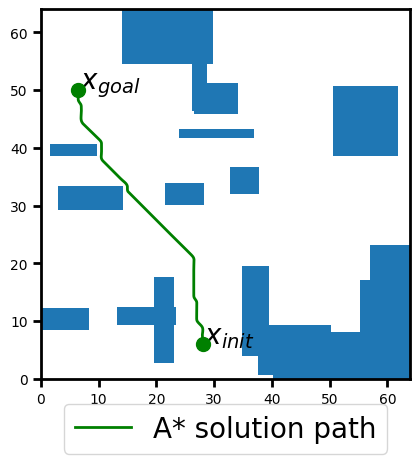

In [41]:
# Construct A* Path
astar = AStar((0, 0), (width, height), x_init, x_goal, occupancy, resolution=0.5)
x_features = [occupied_cells, x_init, x_goal]
if not astar.solve():
    print("No path found!")
else:
    plan = compute_smooth_plan(astar.path)
    astar.path = list(plan.smoothed_path())
    y_path = np.asarray(astar.path)
    astar.plot_path()